# Active Matter - DS Study

A matéria ativa é uma área da física, derivada da mecânica estatística de Não-Equilíbrio e da *soft matter*. <br>
Estuda, em resumo, sistemas compostos por unidades que, individualmente, consomem energia para gerar movimento. <br>


## Active Brownian Particle (ABP)

Dentre alguns tipos de Matérias ativas, temos as **Partículas Brownianas Ativas**.

Pode-se definir uma ABP como uma partícula que possui velocidade de autopropulsão constante $v_0$ ao longo de <br> um eixo de orientação $\hat{n}$, cuja direção tende a mudar, devido à difusão rotacional, estocasticamente.

Para o caso em duas dimensões (2D), o movimento será descrito pela **Dinâmica de Langevin**: <br>


$$
  \mathbf{\dot{r}}(t) = v_{0}\mathbf{\hat{n}}(\phi) + \sqrt{2D_{t}}\xi_{t}(t)
$$  
<br>
$$
\dot{\phi}(t) = \sqrt{2D_r}\xi_{r}(t)
$$

Onde:

*   $\mathbf{r}(t)$ é a posição da partícula.
*   $\hat{\mathbf{n}}(\phi) = (\cos\phi, \sin\phi)$ é o vetor unitário de orientação.
*   $D_t$ e $D_r$ são os coeficientes de difusão translacional e rotacional, respectivamente.
*   $\boldsymbol{\xi}_t$ e $\xi_r$ representam o ruído branco Gaussiano (flutuações térmicas) com média zero e correlação delta.
*   $v_0$ é a velocidade inicial de autopropulsão

In [ ]:
import numpy as np

In [ ]:
n_particles = 8
v0 = 2.0
Dr = 0.7
Dt = 0.3
dt = 0.001
total_time = 500.0

n_steps = int(total_time / dt)

Usando o método de Euler-Maruyama para aproximações de primeira ordem, temos:

$$
\phi_{i+1} = \phi_{i} + 2D_r \Delta t\cdot \xi_{\phi}
$$ <br>
$$
x_{i+1} = x_{i} + 2D_t \Delta t\cdot \xi_{x}
$$ <br>
$$
y_{i+1} = y_{i} + 2D_t \Delta t\cdot \xi_{y}
$$ <br>

In [ ]:
def generate_dynamic(velocity: float, particles: int, steps: int,
                     rotational_D: float, translational_D: float, step_dt: float) -> dict:
    """
    Gera a dinâmica da ABP via Euler-Maruyama.
    Retorna um dicionário contendo as trajetórias e metadados.
    """
    x = np.zeros((steps, particles))
    y = np.zeros((steps, particles))
    phi = np.zeros((steps, particles))

    time_array = np.arange(steps) * step_dt

    # Condições inicias em t=0
    phi[0, :] = np.random.uniform(0, 2*np.pi, particles)
    x[0, :] = np.random.uniform(-1, 1, particles)
    y[0, :] = np.random.uniform(-1, 1, particles)

    sqrt_dt_trans = np.sqrt(2 * translational_D * step_dt)
    sqrt_dt_rot = np.sqrt(2 * rotational_D * step_dt)

    for t in range(steps - 1):
        noise_x = np.random.normal(0, sqrt_dt_trans, particles)
        noise_y = np.random.normal(0, sqrt_dt_trans, particles)
        noise_phi = np.random.normal(0, sqrt_dt_rot, particles)

        phi[t+1, :] = phi[t, :] + noise_phi

        x[t+1, :] = x[t, :] + (velocity * np.cos(phi[t, :]) * step_dt) + noise_x
        y[t+1, :] = y[t, :] + (velocity * np.sin(phi[t, :]) * step_dt) + noise_y

    return {
        "x": x,
        "y": y,
        "phi": phi,
        "time": time_array,
        "parameters": { #Metadados
            "v0": velocity,
            "Dr": rotational_D,
            "Dt": translational_D,
            "dt": step_dt,
            "n_particles": particles
        }
    }

In [ ]:
import matplotlib.pyplot as plt

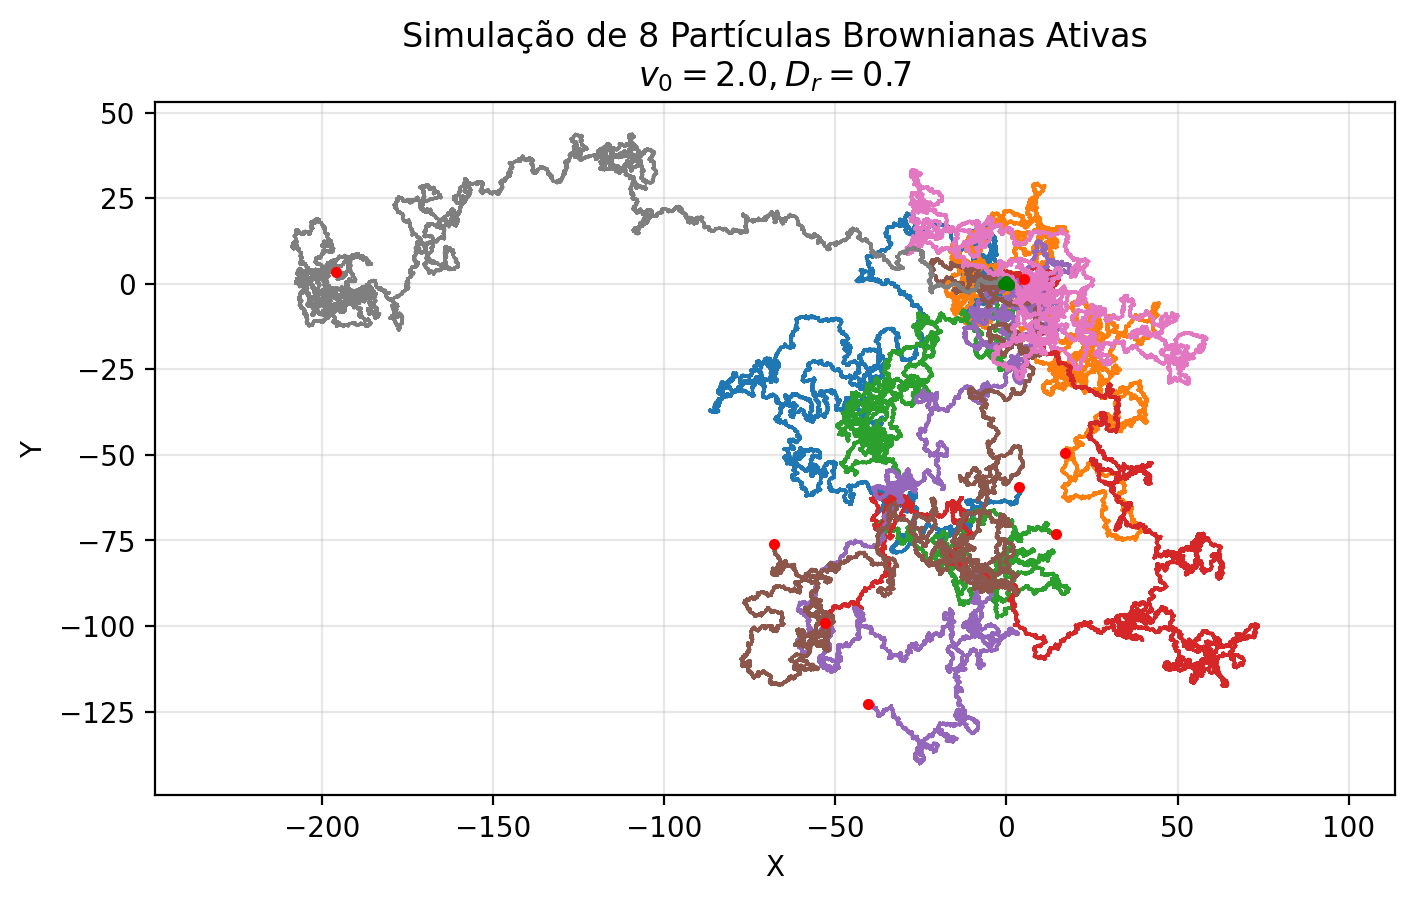

In [ ]:
simulacao = generate_dynamic(v0, n_particles, n_steps,
                             Dr, Dt, dt)
x = simulacao['x']
y = simulacao['y']

plt.figure(figsize=(8,4.5), dpi=200)
plt.plot(x, y, lw=1)
plt.plot(x[0][:], y[0][:], 'go', ms=3)
plt.plot(x[-1][:], y[-1][:], 'ro', ms=3)


plt.title(f"Simulação de {simulacao['parameters']['n_particles']} Partículas Brownianas Ativas\n$v_0={simulacao['parameters']['v0']}, D_r={simulacao['parameters']['Dr']}$")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal') # Importante para não distorcer a visualização da trajetória
plt.grid(True, alpha=0.3)
plt.show()